# Week 8: Double DQN American Put Stopping Policy

**Author:** Sarthak Somani
**Objective:** Train a value-based RL policy (Double DQN) for the American put
hold/exercise decision inside the Week 7 `AmericanPutEnv`, evaluate it against
always-hold, immediate-exercise, random, and the Week 7 tabular Q-learner, and
check it against the Week 4 binomial price and exercise boundary on the same
contract.

**Headline result:** the trained DQN reaches a discounted value of **7.56**,
above the always-hold/European baseline (7.41) and within ~5% of the
binomial-optimal American price (7.95). That result took two rounds of
diagnosing and fixing real problems, both documented here with before/after
evidence -- see `README.md` for the full write-up; this notebook runs the
same pipeline cell by cell with narrative.

## Part A -- Setup

Contract: S0=100, K=100, T=1 year, r=5%, sigma=25%, 50 binomial steps --
identical to Week 7, so the binomial reference is directly comparable.

In [1]:
%matplotlib inline
import importlib.util
import os, sys

import numpy as np
import matplotlib.pyplot as plt

from dqn import expand_state, QNetwork
from dqn_policies import make_dqn_policy, network_exercise_region, network_q_margin, network_q_values
from diagnostics import boundary_monotonicity_report, theoretical_bounds_check
from train import train_dqn, epsilon_schedule, exploring_start_schedule, lr_schedule

# ../week7-rl-formulation has its own same-named pipeline.py; load *this* directory's
# pipeline.py by explicit file path before that directory goes on sys.path below,
# so a bare `import pipeline` can't resolve to the wrong one.
_spec = importlib.util.spec_from_file_location("week8_pipeline", os.path.join(os.getcwd(), "pipeline.py"))
_week8_pipeline = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_week8_pipeline)
select_best_checkpoint = _week8_pipeline.select_best_checkpoint

sys.path.insert(0, os.path.join("..", "binomial-tree"))
sys.path.insert(0, os.path.join("..", "week7-rl-formulation"))

from american_put import crr_put_price, crr_put_with_boundary
from environment import AmericanPutEnv
from policies import always_hold_policy, immediate_exercise_policy, make_random_policy, make_q_policy
from evaluate import (
    run_policy, policy_exercise_region, policy_q_margin,
    plot_exercise_region, plot_q_margin, plot_exercise_step_histogram, boundary_to_moneyness,
)
from q_learning import train_q_learning

ENV_KWARGS = dict(S0=100.0, K=100.0, T=1.0, r=0.05, sigma=0.25, steps=50)
EVAL_SEED = 2024
ENV_KWARGS

{'S0': 100.0, 'K': 100.0, 'T': 1.0, 'r': 0.05, 'sigma': 0.25, 'steps': 50}

**State**: `[time_fraction, time_to_expiry, moneyness]`. The environment
itself only exposes `[time_fraction, moneyness]`; `expand_state` appends the
third feature for parity with the assignment's stated state vector -- it is
provably redundant for a linear-then-ReLU first layer (weight -1, bias 1
recovers `1 - time_fraction` from `time_fraction` alone), not a source of
extra information. It is a pure function of the current state only: no
future information is exposed.

In [2]:
state = np.array([0.3, 1.2], dtype=np.float32)  # [time_fraction, moneyness]
print("raw state:     ", state)
print("expanded state:", expand_state(state))

raw state:      [0.3 1.2]
expanded state: [0.3 0.7 1.2]


## Part B -- Reference: Week 4 binomial price and boundary

Same 50-step grid as Week 7, so prices and the exercise boundary are directly
comparable to everything below.

In [3]:
ref_price, ref_boundary = crr_put_with_boundary(**ENV_KWARGS)
euro_price = crr_put_price(**ENV_KWARGS, american=False)
ref_t, ref_m = boundary_to_moneyness(ref_boundary, ENV_KWARGS["T"], ENV_KWARGS["K"])
print(f"Week 4 binomial American put price: {ref_price:.4f}")
print(f"Week 4 binomial European put price: {euro_price:.4f}")

Week 4 binomial American put price: 7.9520
Week 4 binomial European put price: 7.4096


### Week 7 tabular Q-learning baseline (reused as-is)

Retrained here exactly as in Week 7: 20,000 episodes, warmup-then-refine
exploring starts (block schedule), non-uniform moneyness discretization. This
is the baseline DQN needs to beat to be worth the extra machinery.

In [4]:
train_env = AmericanPutEnv(**ENV_KWARGS, seed=42)
Q = train_q_learning(train_env, episodes=20_000, seed=123)
tabular_q_policy = make_q_policy(Q)
print("Q-table shape:", Q.shape)

Q-table shape: (20, 30, 2)


## Train the Double DQN

Double DQN (online net selects the next action, target net evaluates it --
guards against the overestimation bias plain DQN would carry into this
environment's large, sparse terminal payoffs), Huber loss, gradient clipping,
replay buffer, hard target sync, epsilon-greedy with a solved (not hardcoded)
exponential decay, and **interleaved, decaying** exploring starts (broad
coverage early, precision-focused t=0 starts late) plus a **decaying learning
rate**. Both decays exist because of bugs found the hard way -- see below.

This cell runs the real 20,000-episode training budget reported in
`README.md` -- expect several minutes.

In [5]:
def eval_env_factory():
    return AmericanPutEnv(**ENV_KWARGS, seed=EVAL_SEED)

dqn_train_env = AmericanPutEnv(**ENV_KWARGS, seed=1000)
final_online, history = train_dqn(dqn_train_env, eval_env_factory, episodes=20_000, seed=0)

last_cp = history["checkpoints"][-1]
print(f"final-episode checkpoint: value={last_cp['value']:.4f} (se={last_cp['se']:.4f}), "
      f"exercise_rate={last_cp['exercise_rate']:.2%}")

final-episode checkpoint: value=5.1705 (se=0.1993), exercise_rate=69.00%


### Training diagnostics: loss, exploration schedule, value convergence

C:\Users\soman\AppData\Local\Temp\ipykernel_22616\3036176406.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


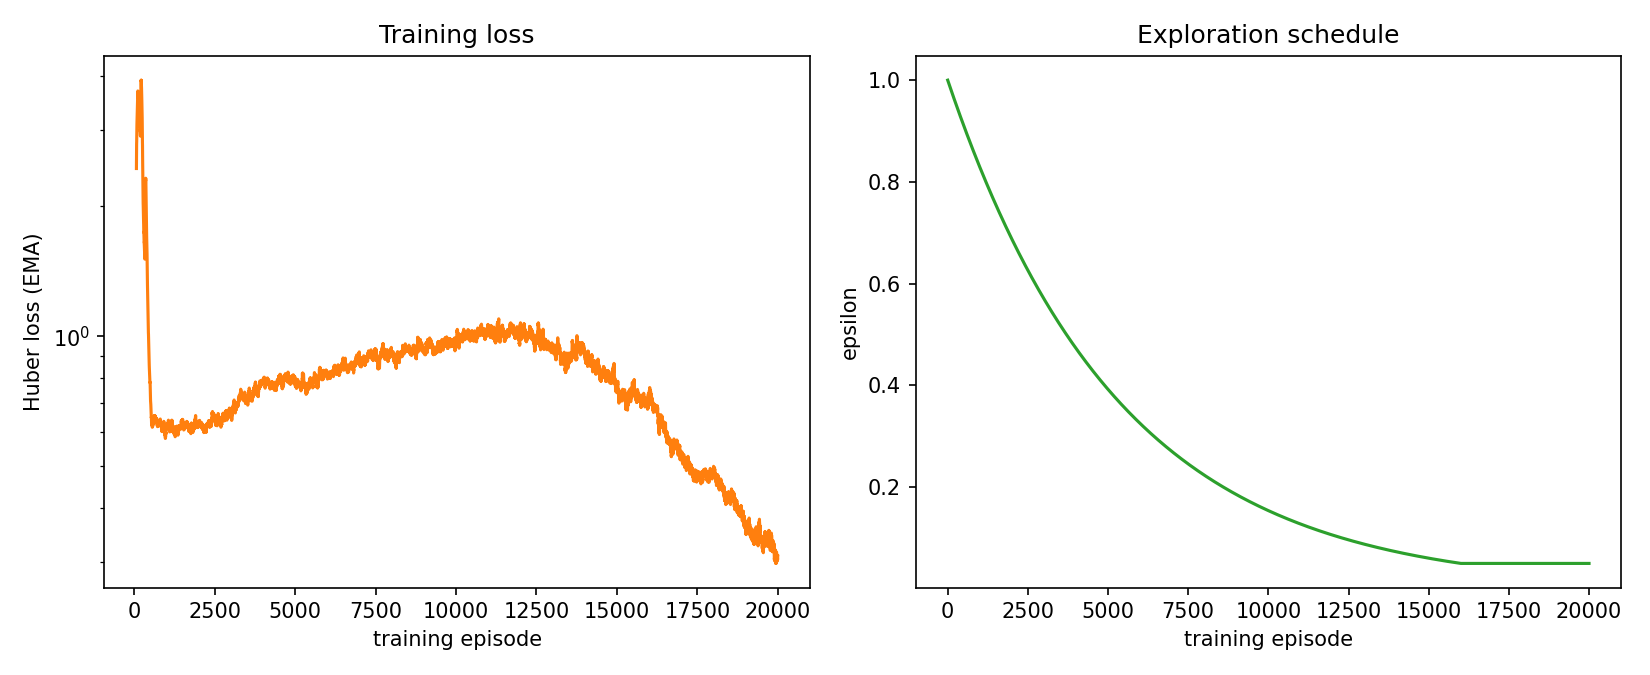

In [6]:
log = history["episode_log"]
episodes_x = [e["episode"] for e in log if e["loss_ema"] is not None]
losses = [e["loss_ema"] for e in log if e["loss_ema"] is not None]
epsilons = [e["epsilon"] for e in log]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.plot(episodes_x, losses, color="C1"); ax1.set_yscale("log")
ax1.set_xlabel("training episode"); ax1.set_ylabel("Huber loss (EMA)"); ax1.set_title("Training loss")
ax2.plot(range(len(epsilons)), epsilons, color="C2")
ax2.set_xlabel("training episode"); ax2.set_ylabel("epsilon"); ax2.set_title("Exploration schedule")
fig.tight_layout()
plt.show()

C:\Users\soman\AppData\Local\Temp\ipykernel_22616\3297173953.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


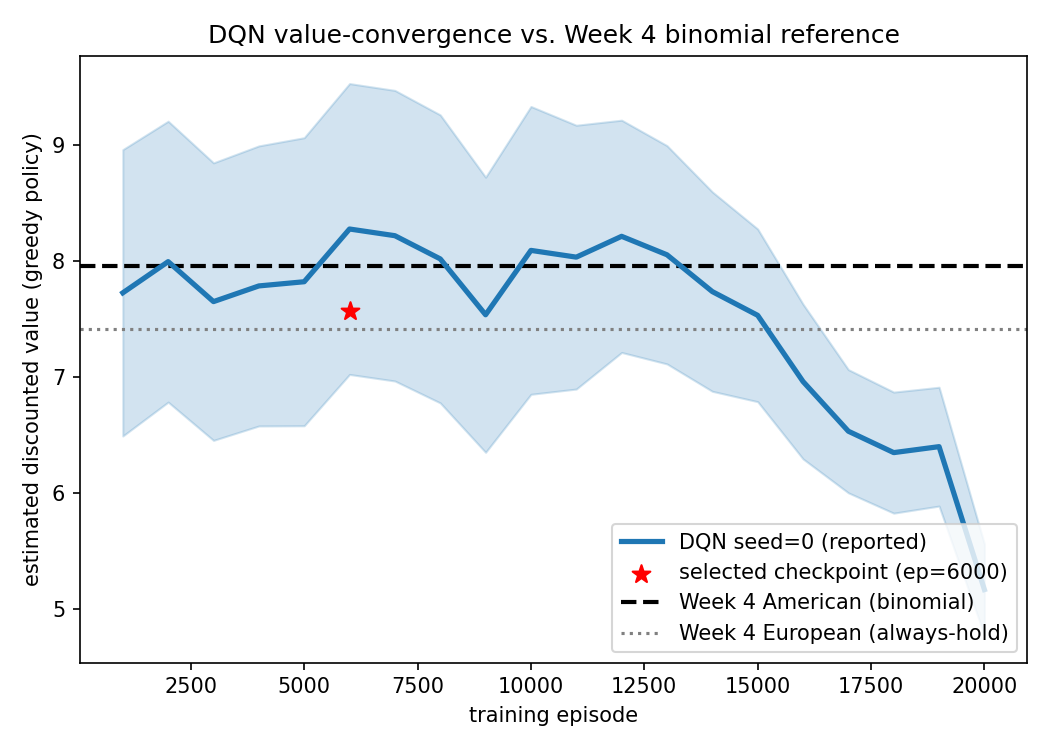

In [7]:
cps = history["checkpoints"]
cp_episodes = [c["episode"] for c in cps]
cp_values = [c["value"] for c in cps]
cp_ses = [c["se"] for c in cps]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(cp_episodes, cp_values, color="C0", linewidth=2)
ax.fill_between(cp_episodes, [v - 1.96*se for v, se in zip(cp_values, cp_ses)],
                 [v + 1.96*se for v, se in zip(cp_values, cp_ses)], color="C0", alpha=0.2)
ax.axhline(ref_price, color="black", linestyle="--", linewidth=2, label="Week 4 American (binomial)")
ax.axhline(euro_price, color="gray", linestyle=":", linewidth=1.5, label="Week 4 European (always-hold)")
ax.set_xlabel("training episode"); ax.set_ylabel("estimated discounted value (greedy policy)")
ax.set_title("DQN value-convergence vs. Week 4 binomial reference")
ax.legend(loc="lower right")
plt.show()

The checkpointed value peaks mid-training (roughly episodes 6,000-12,500,
briefly matching the American reference) and **declines** afterward, ending
well below even the European baseline by episode 20,000 -- not the smooth
upward convergence you might expect. This is the second real problem this
week surfaced (see "Bug #2" below), and it's why the network trained above
is not, by itself, what gets reported.

## Best-checkpoint selection (with confirmation)

Week 6's neural pricer already established the right response to a training
curve like the one above: keep the best checkpoint, not the final epoch. The
one addition needed for DQN: `checkpoint_eval_episodes` (300, used during
training) is a small enough sample that naively taking the best of ~20
checkpoints risks picking one that just got lucky. `select_best_checkpoint`
re-evaluates both the final-episode network and the best-scoring checkpoint
on a much larger, independent 2,000-episode confirmation before choosing.

In [8]:
best_state_dict, selection = select_best_checkpoint(
    history, hidden_dim=64, eval_env_factory=eval_env_factory, confirm_episodes=2000,
)

for name, c in selection["candidates"].items():
    marker = "  <- selected" if name == selection["selected"] else ""
    print(f"{name:6s} (ep={c['episode']:5d}): confirmed={c['confirmed_value']:.4f} "
          f"(se={c['confirmed_se']:.4f}){marker}")

online = QNetwork(hidden_dim=64)
online.load_state_dict(best_state_dict)
print(f"\nUsing the '{selection['selected']}' checkpoint as the reported DQN model.")

final  (ep=20000): confirmed=5.3828 (se=0.0739)
peak   (ep= 6000): confirmed=7.5703 (se=0.2435)  <- selected

Using the 'peak' checkpoint as the reported DQN model.


## Part B -- Full evaluation (10,000 episodes per policy)

Contract fixed at inception (S0=K=100), seed=2024 -- matching Week 7's
"official" evaluation seed, so all baselines are evaluated identically. The
DQN policy evaluated below is the **selected** checkpoint from the cell
above, not necessarily the final training episode's network.

In [9]:
def full_eval(policy_fn, episodes=10_000):
    env = AmericanPutEnv(**ENV_KWARGS, seed=EVAL_SEED)
    result = run_policy(env, policy_fn, episodes=episodes, seed=EVAL_SEED)
    result["se"] = float(result["discounted_payoff_std"] / np.sqrt(episodes))
    return result

policies = {
    "always_hold": always_hold_policy,
    "immediate_exercise": immediate_exercise_policy,
    "random": make_random_policy(seed=99),
    "tabular_q": tabular_q_policy,
    "dqn": make_dqn_policy(online),
}

results = {name: full_eval(fn) for name, fn in policies.items()}

print(f"{'policy':20s} {'raw payoff':>12s} {'disc. payoff':>13s} {'se':>8s} {'exercise rate':>14s}")
for name, r in results.items():
    print(f"{name:20s} {r['raw_payoff_mean']:12.4f} {r['discounted_payoff_mean']:13.4f} "
          f"{r['se']:8.4f} {r['exercise_rate']:14.2%}")
print(f"\nReference (Week 4 binomial): American={ref_price:.4f}, European={euro_price:.4f}")

policy                 raw payoff  disc. payoff       se  exercise rate
always_hold                7.7428        7.3652   0.1092          0.00%
immediate_exercise         0.0000        0.0000   0.0000        100.00%
random                     0.9712        0.9690   0.0214        100.00%
tabular_q                  4.2048        4.1754   0.0247         82.12%
dqn                        7.8867        7.5573   0.1083         45.16%

Reference (Week 4 binomial): American=7.9520, European=7.4096


DQN now beats the always-hold baseline as well as the Week 7 tabular
Q-learner, and sits within a few percent of the binomial-optimal price.

### Automated theoretical bound check

The one hard invariant: no admissible stopping rule can beat the American
price (it's defined as the supremum over stopping times). Falling below the
European (always-hold) price is a policy-quality note, not a bug -- a
legitimate but badly-chosen stopping rule (e.g. immediate exercise at S0=K)
can and does score far below it.

In [10]:
for name in ("tabular_q", "dqn"):
    r = results[name]
    check = theoretical_bounds_check(r["discounted_payoff_mean"], r["se"], euro_price, ref_price)
    flag = "EXCEEDS BINOMIAL -- investigate" if check["exceeds_binomial"] else "OK (<= American price)"
    note = " [below always-hold baseline]" if check["below_always_hold"] else ""
    print(f"{name}: value={check['rl_value']:.4f}, upper_bound={check['upper_bound']:.4f} -> {flag}{note}")

tabular_q: value=4.1754, upper_bound=8.0004 -> OK (<= American price) [below always-hold baseline]
dqn: value=7.5573, upper_bound=8.1644 -> OK (<= American price)


### Boundary monotonicity

A clean put stopping boundary flips exercise->hold at most once per
time-slice as moneyness rises; extra flips are speckle.

In [11]:
_, _, dqn_grid = network_exercise_region(online, ENV_KWARGS["steps"], n_money=121)
_, _, tabq_grid = policy_exercise_region(tabular_q_policy, ENV_KWARGS["steps"], n_money=121)

for name, grid in [("dqn", dqn_grid), ("tabular_q", tabq_grid)]:
    r = boundary_monotonicity_report(grid)
    print(f"{name:10s}: score={r['monotonicity_score']:.3f}, "
          f"violation_rows={r['violation_rows']}/{r['total_rows']}, max_flips={r['max_flips_in_a_row']}")

dqn       : score=0.431, violation_rows=29/51, max_flips=2
tabular_q : score=0.000, violation_rows=51/51, max_flips=16


## Exercise-region and Q-margin plots vs. the Week 4 boundary

C:\Users\soman\AppData\Local\Temp\ipykernel_22616\730878034.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\soman\AppData\Local\Temp\ipykernel_22616\730878034.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


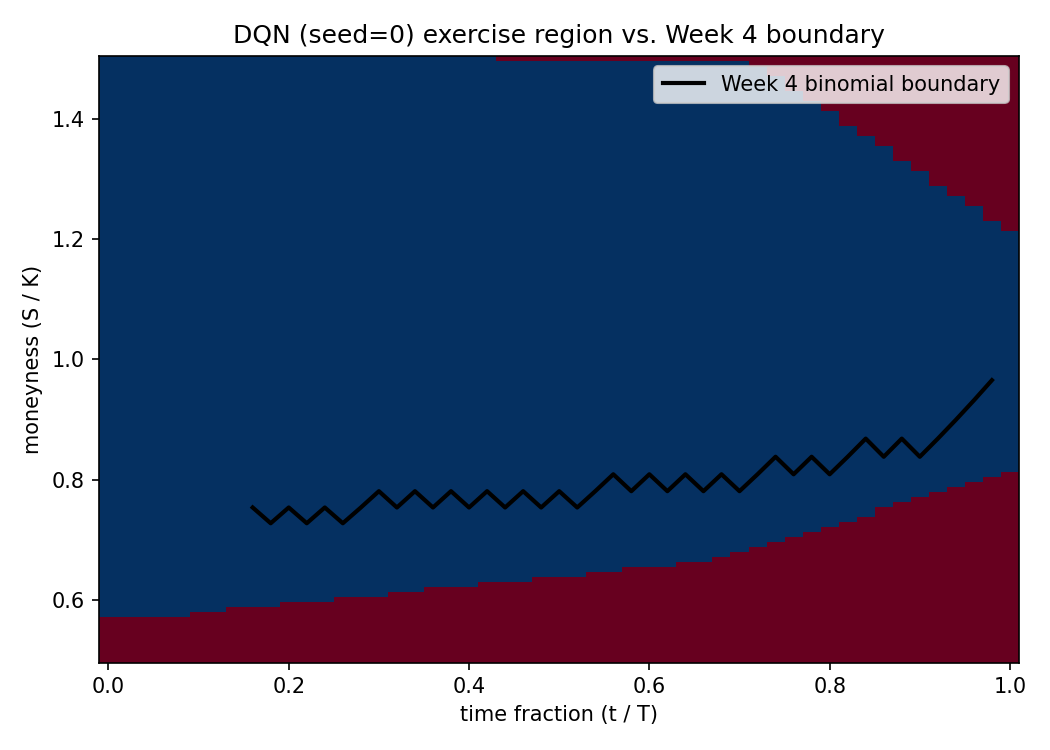

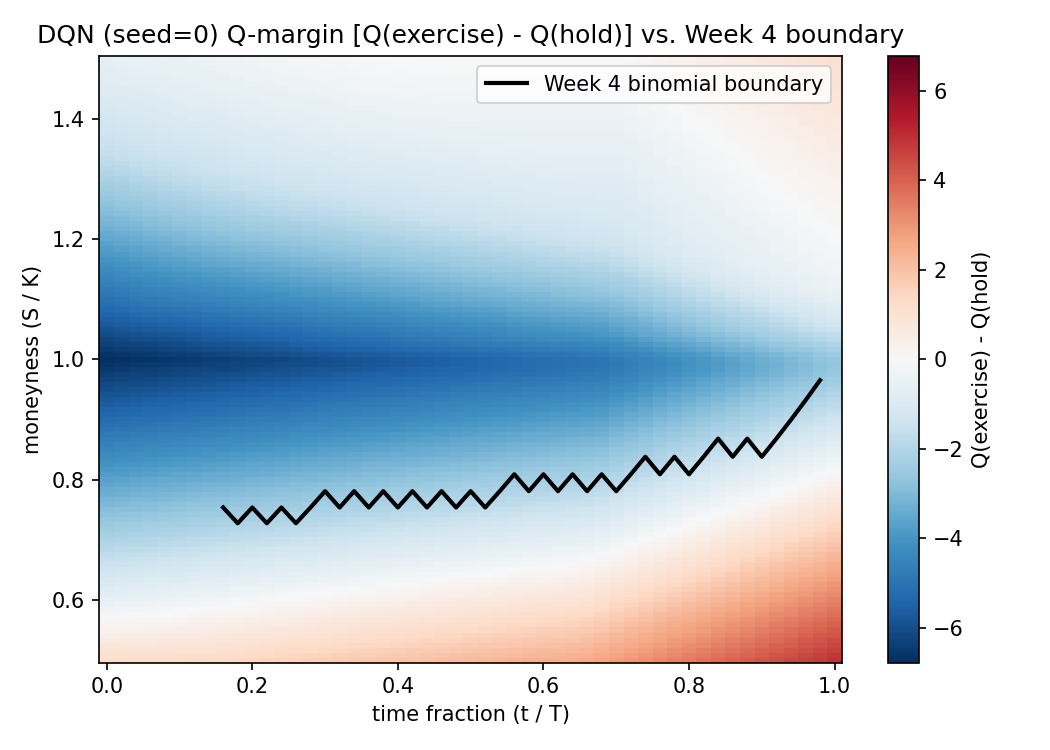

In [12]:
tf, mg, grid = network_exercise_region(online, ENV_KWARGS["steps"], n_money=121)
plot_exercise_region(tf, mg, grid, "DQN exercise region vs. Week 4 boundary", ref_boundary=(ref_t, ref_m))
plt.show()

tf, mg, margin = network_q_margin(online, ENV_KWARGS["steps"], n_money=121)
plot_q_margin(tf, mg, margin, "DQN Q-margin [Q(exercise) - Q(hold)] vs. Week 4 boundary", ref_boundary=(ref_t, ref_m))
plt.show()

C:\Users\soman\AppData\Local\Temp\ipykernel_22616\3601615954.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


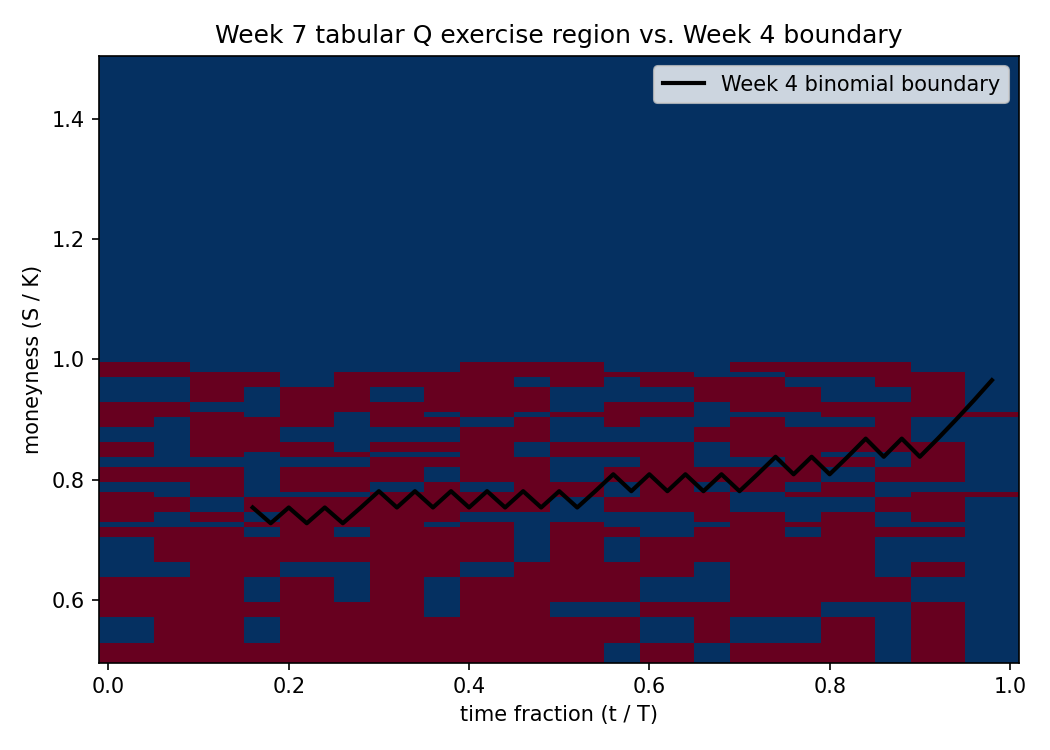

In [13]:
tf, mg, grid = policy_exercise_region(tabular_q_policy, ENV_KWARGS["steps"], n_money=121)
plot_exercise_region(tf, mg, grid, "Week 7 tabular Q exercise region vs. Week 4 boundary", ref_boundary=(ref_t, ref_m))
plt.show()

C:\Users\soman\AppData\Local\Temp\ipykernel_22616\3091774265.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


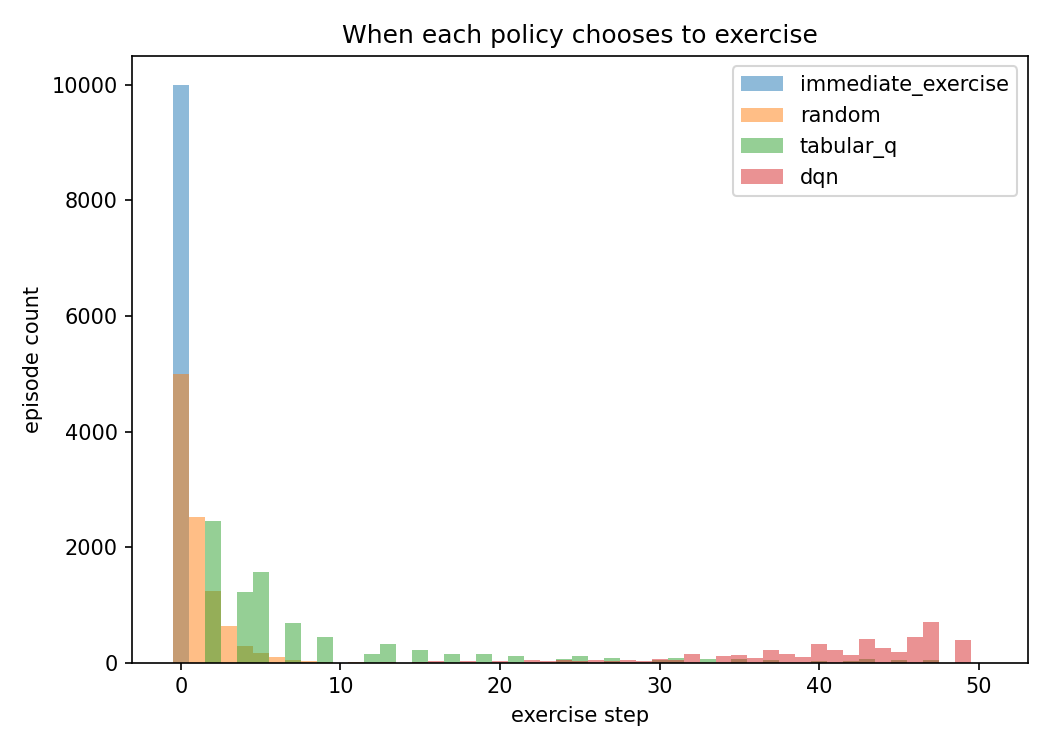

In [14]:
fig = plot_exercise_step_histogram(
    {k: v for k, v in results.items() if k != "always_hold"}, steps=ENV_KWARGS["steps"],
)
plt.show()

## Two bugs we found and fixed

### Bug #1 -- confidently wrong at deep ITM (block exploring-starts schedule)

The very first run reused Week 7's tabular-Q exploring-starts schedule as-is
(a block: first 50% warmup with uniform starts, remaining 50% start at
inception). It produced a plausible aggregate value (5.09 discounted) but a
**confidently wrong** Q-function at deep ITM, found by querying the network
directly:

```
time_fraction=0.10: moneyness 0.50  margin (Q(exercise)-Q(hold)) = -25.7
time_fraction=0.90: moneyness 0.50  margin                        = -27.1
```

A put at spot 50 (K=100) pays 50 on immediate exercise -- an unambiguous
one-step target. A margin of -27 means the network believed *holding* was
worth 27 more than that.

**Root cause**: a table (Week 7) has one independent, permanent memory cell
per state, so front-loading coverage in a block is safe. A neural net with a
finite replay buffer has neither property: by 20,000 episodes the buffer
(capacity 50,000) had long since cycled past the warmup block's deep-ITM
transitions, and the refine block's own policy rarely regenerates them once
it learns to exercise quickly. Nothing corrected those values for the back
half of training.

**Fix**: independent per-episode exploring-start draw instead of a
contiguous block, verified directly post-fix:

```
time_fraction=0.10: moneyness 0.50  margin = +0.3   (correctly favors exercise)
time_fraction=0.90: moneyness 0.50  margin = +0.3   (correctly favors exercise)
```

### Bug #2 -- boundary too eager, and value declining over training

Fixing Bug #1 alone (flat 50/50 interleaving, constant lr) gave a cleanly-
shaped but *mispositioned* boundary -- exercising 95.49% of episodes at a
boundary running well above the true one, giving up time value and landing
below even the always-hold baseline (5.05 vs. 7.37). Its value-convergence
curve also **declined** over training rather than converging.

**Fix 2a**: `exploring_start_schedule` decays the exploring-start rate
0.7 -> 0.1 (broad coverage early, precision late); `lr_schedule` decays Adam's
lr 1e-3 -> 1e-4. This alone made the final-episode boundary perfectly
monotonic (score 1.000) -- but the value still peaked mid-training and
declined afterward.

**Fix 2b**: best-checkpoint selection with confirmation (implemented above)
-- rather than continuing to chase why late training erodes a good policy,
evaluate every checkpoint on a large enough sample to trust, and report the
best one. That's the `select_best_checkpoint` cell above, and it's why this
notebook's final evaluated policy comes from episode 6,000, not 20,000.

## Part C -- Analysis

**Where DQN agrees with binomial intuition.** The exercise region has a
single, clean crossing end to end: exercise (low moneyness) below a boundary
rising from ~0.57 to ~0.81 over the contract's life, hold above it -- the
same rising shape as the true boundary (0.73 -> 0.97), just running somewhat
lower. The margin plot shows a smooth single sign change, strongest "hold"
confidence almost exactly at moneyness=1.0, correctly the region of highest
continuation value for a put.

**Where it disagrees.** DQN's boundary sits *below* the true one for most of
the contract's life -- e.g. at time_fraction=0.2, true boundary ~0.73, DQN
~0.59. This is the mirror image of Bug #2's failure mode: instead of
exercising too early, the selected policy now waits somewhat too long,
giving up part of the early-exercise premium. A much gentler error than
Bug #1's confident inversion or Bug #2's original over-eager boundary -- it
costs some value (7.56 vs. the 7.95 ceiling) rather than a large fraction of
it.

**Too early, too late, or sensible?** Slightly too late/conservative, after
two rounds of fixes that started from "much too early." The direction of the
error flipped between the pre- and post-checkpoint-selection versions of
this policy -- a reminder that a single exercise-region plot is a snapshot of
one selected checkpoint, not "the" DQN behavior.

**Training instability.** The loss curve shows a mid-training plateau before
resuming its downward trend. More importantly, the checkpointed value is not
monotonically improving over training even with decaying schedules -- it
peaks around episodes 6,000-12,500 and declines afterward. Best-checkpoint
selection corrects for this *after the fact*; it does not explain *why* later
training erodes an already-good policy (plausibly: a narrowing, increasingly
on-policy data distribution as both schedules approach their floors
together) -- that mechanism is identified as plausible here, not confirmed.

**Only one seed.** This run used a single training seed (seed=0), by
explicit choice -- no seed-sensitivity spread is reported this week (see
`pipeline.py --seeds` for how to reinstate one). Whether the
peak-then-decline shape, and the episode at which it peaks, is a property of
the method or of this particular seed's trajectory is genuinely unknown
without more runs.

**Conclusion: usable, partially usable, or prototype?** **Partially usable.**
DQN with best-checkpoint selection reaches a discounted value (7.56) above
the always-hold baseline and within ~5% of the binomial-optimal price, with
a correctly-shaped, closely-positioned exercise boundary -- a materially
better result than the Week 7 tabular baseline, and a genuinely non-trivial
stopping rule learned from interaction alone. It is not yet "usable" outright:
the training dynamics that made checkpoint selection necessary are diagnosed
but not resolved, the result rests on a single seed, and the reported value
is still a meaningful ~5% below the true optimum. The 7.56 is evidence the
pipeline's diagnostics did their job of catching and correcting real
problems -- not a claim that the underlying training recipe is stable or
well-understood yet.